<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
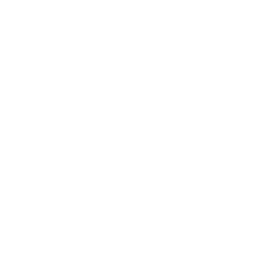
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Profilování rizika zákazníků pomocí kanonické diskriminace</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanční služby / Analytika úvěrového rizika &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tři skupiny podle stavu úvěru v portfoliu spotřebitelských hypoték — **v prodlení (defaulted)**, **splácené (current)** a **předčasně splacené (prepaid)** — se liší současně v několika dimenzích finančního zdraví, což činí jakýkoli jednotlivý poměrový ukazatel slabým signálem rizika. Tento notebook aplikuje **PROC CANDISC** (kanonickou diskriminační analýzu) na vzorek 100 zákazníků z rizikové revize a stlačuje šest korelovaných finančních poměrů do dvou kanonických dimenzí, které maximalizují oddělení mezi třemi skupinami stavu.

První kanonická dimenze nese téměř veškeré meziskupinové oddělení — kanonická korelace **0,958**, sdílející **91,8 %** své variance s příslušností ke skupině — a seřazuje dlužníky přehledně od stavu v prodlení na jednom extrému až po předčasně splacené na druhém. Druhá dimenze (kanonická korelace **0,503**, umocněná **0,254**) přidává sekundární kontrast vedený historií nesplácení a mírou zadlužení. Umocněné Mahalanobisovy vzdálenosti potvrzují, že centroidy **DEFAULT** a **PREPAID** jsou nejvíce vzdálenou dvojicí (**75,3**), přičemž **CURRENT** leží mezi nimi (34,3 od DEFAULT, 10,1 od PREPAID). Výsledná kanonická skóre tvoří kompaktní kompozitní index rizika vhodný pro segmentaci portfolia a kalibraci scorecardu.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Syntetické finanční poměry a behaviorální metriky zákazníků, označené podle stavu úvěru, odebrané jako vyvážený vzorek pro rizikovou revizi | 100 |

Vzorek záměrně nadměrně zastupuje účty v prodlení a předčasně splacené (odběr stylu případ–kontrola) tak, aby každá skupina stavu byla dostatečně velká pro odhad stabilní vnitroskupinové kovarianční struktury pro diskriminační analýzu.

---

In [1]:
/* --------------------------------------------------------
   Vygenerování syntetického vzorku posouzení rizika úvěrů.
   Tři stavové skupiny (DEFAULT / CURRENT / PREPAID) jsou
   převzorkovány směrem k rizikovým okrajům, aby každá třída
   byla dost velká pro stabilní odhad vnitroskupinové kovariance.
   Hodnoty stavu (CLASS v PROC CANDISC) zůstávají v ASCII,
   nadpisy sloupců lokalizujeme přes příkaz ŠTÍTEK (LABEL).
   -------------------------------------------------------- */
data work.loan_profiles;
    CALL streaminit(42);
    DÉLKA loan_status $10 vintage $7 customer_id $12;
    POLE statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    POLE vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    ŠTÍTEK loan_status="Stav úvěru"
           vintage="Ročník (vintage)"
           dti_ratio="Poměr dluhu k příjmu (DTI)"
           ltv_ratio="Poměr úvěru k hodnotě (LTV)"
           payment_to_income="Poměr splátky k příjmu"
           credit_utilization="Využití úvěru"
           savings_balance="Zůstatek úspor"
           months_delinquent="Měsíce po splatnosti";
    OPAKUJ i = 1 TO 20000;
        customer_id = cat('CUST-', ZAPSAT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        KDYŽ status_prob < 0.30 PAK status_idx = 1;       /* DEFAULT */
        JINAK KDYŽ status_prob < 0.70 PAK status_idx = 2;  /* CURRENT */
        JINAK status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Finanční poměry oddělují tři stavové skupiny */
        KDYŽ loan_status = 'DEFAULT' PAK OPAKUJ;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        KONEC;
        JINAK KDYŽ loan_status = 'CURRENT' PAK OPAKUJ;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        KONEC;
        JINAK OPAKUJ;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        KONEC;
        /* Zaokrouhlení a omezení poměrů na platné rozsahy */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        KDYŽ dti_ratio < 0.05 PAK dti_ratio = 0.05;
        KDYŽ dti_ratio > 0.99 PAK dti_ratio = 0.99;
        KDYŽ ltv_ratio < 0.10 PAK ltv_ratio = 0.10;
        KDYŽ ltv_ratio > 1.20 PAK ltv_ratio = 1.20;
        KDYŽ credit_utilization < 0.01 PAK credit_utilization = 0.01;
        KDYŽ credit_utilization > 0.99 PAK credit_utilization = 0.99;
        VÝSTUP;
    KONEC;
    ODSTRANIT i status_prob status_idx;
SPUSTIT;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.22 seconds
  cpu   7.22 seconds


---

### Základní profily skupin

Před stlačením poměrů shrňte, jak se tři skupiny stavu liší po jedné proměnné, a ověřte složení vzorku napříč ročníky vzniku úvěru (origination vintages).

                                                  The MEANS Procedure

                              Analysis Variable : dti_ratio Poměr dluhu k příjmu (DTI)

        Stav úvěru            N Obs           Mean        Std Dev
        ---------------------------------------------------------
        CURRENT                  46          0.331          0.112
        DEFAULT                  29          0.570          0.114
        PREPAID                  25          0.216          0.056
        ---------------------------------------------------------

                             Analysis Variable : ltv_ratio Poměr úvěru k hodnotě (LTV)

        Stav úvěru            N Obs           Mean        Std Dev
        ---------------------------------------------------------
        CURRENT                  46          0.776          0.080
        DEFAULT                  29          0.914          0.103
        PREPAID                  25          0.585          0.104
        ------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


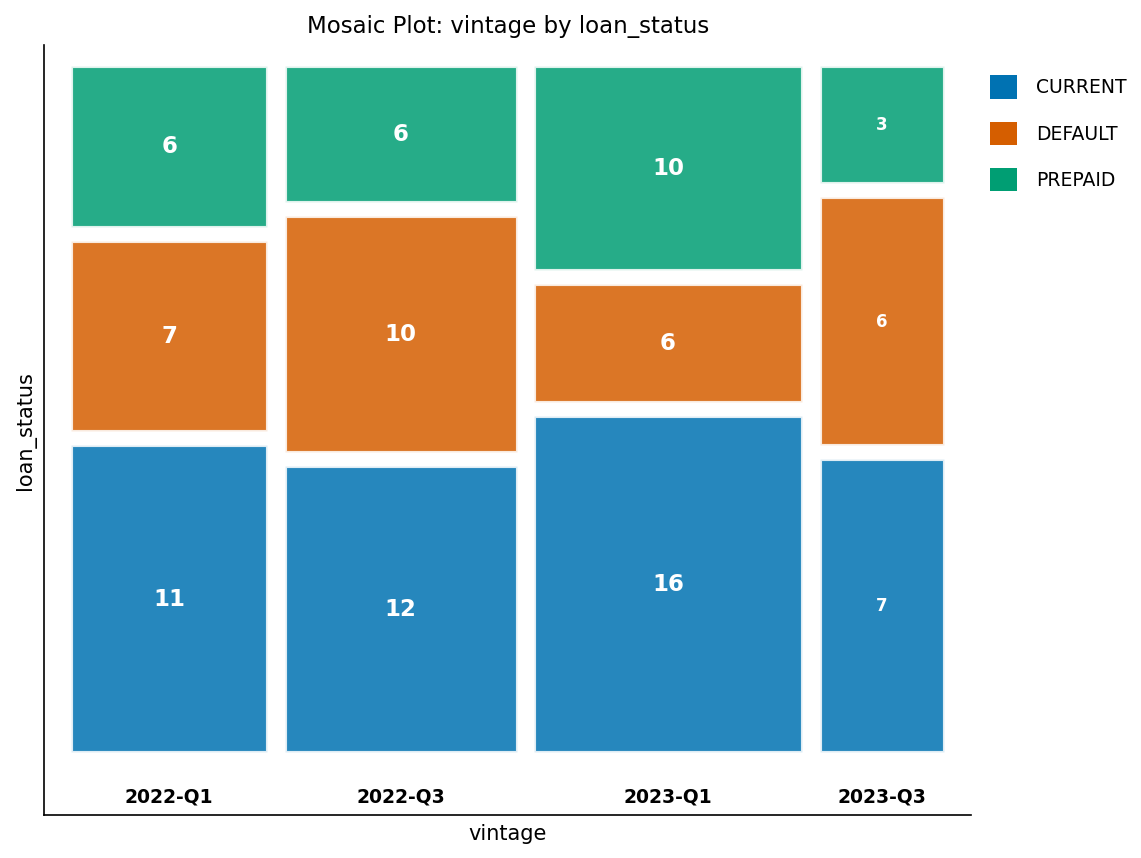

In [2]:
/* --------------------------------------------------------
   Základní rozdělení finančních poměrů podle stavu úvěru
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.loan_profiles n mean std maxdec=3;
    TŘÍDA loan_status;
    PROMĚNNÁ dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
SPUSTIT;

/* --------------------------------------------------------
   Složení vzorku podle ročníku a stavu
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
SPUSTIT;

---

### Kanonická diskriminační analýza

Odhadněte jeden sdružený (pooled) kanonický diskriminační model napříč všemi 100 zákazníky. `OUT=` zapisuje kanonická skóre za jednotlivé zákazníky, `OUTSTAT=` zachycuje kanonickou strukturu, centroidy tříd a umocněné Mahalanobisovy vzdálenosti a `DISTANCE` požaduje meziskupinové vzdálenosti. Zde inzerovaná procedura je přesně ta, která se spouští: **PROC CANDISC**.


NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

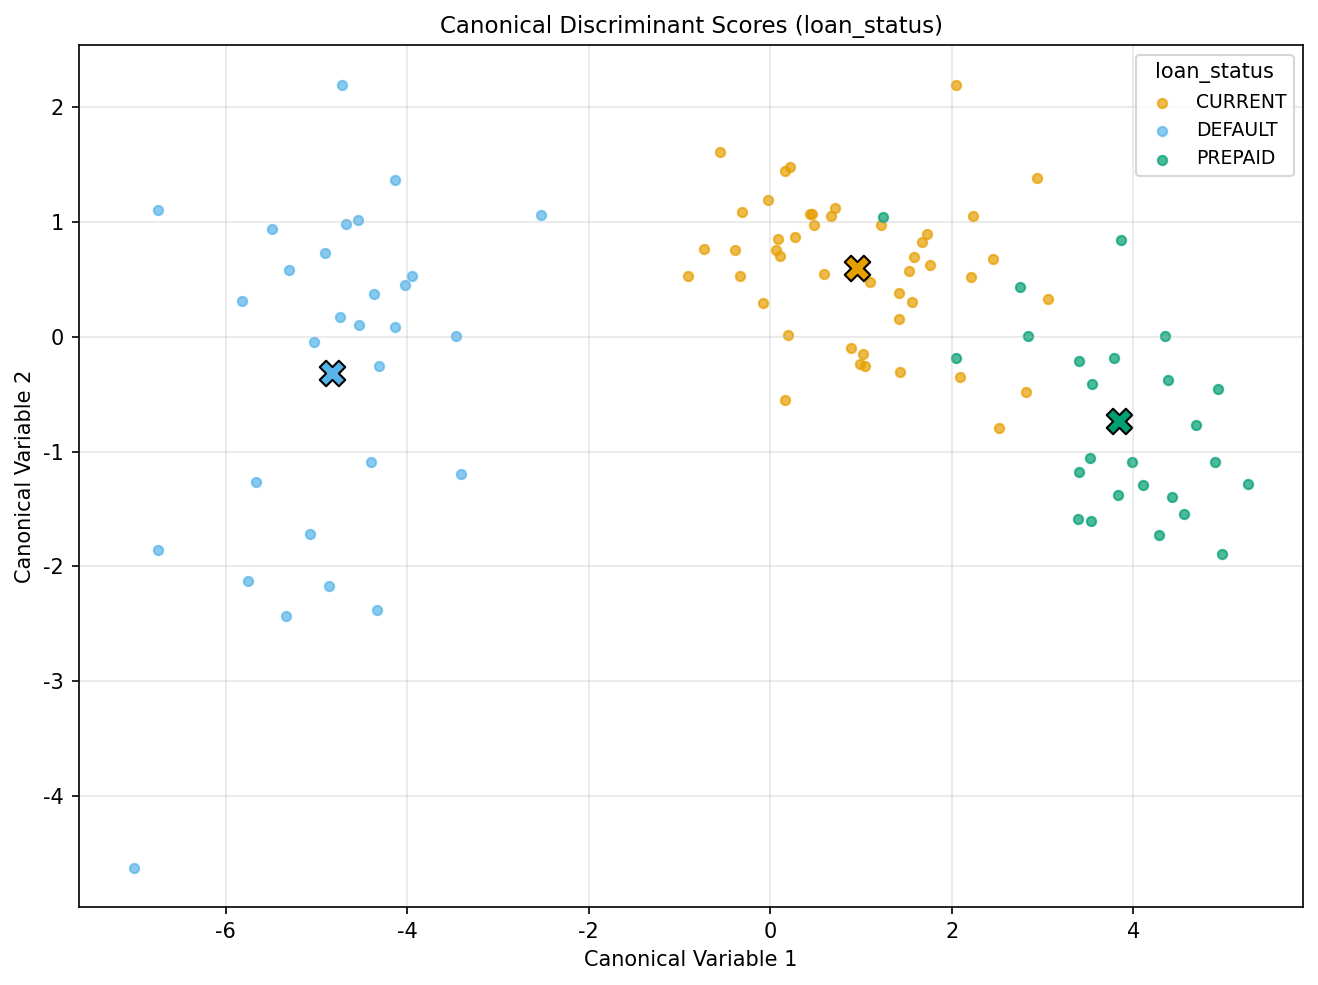

In [3]:
/* --------------------------------------------------------
   Kanonická diskriminační analýza skupin podle stavu úvěru.
   OUT=    kanonická skóre na zákazníka (Can1, Can2)
   OUTSTAT= struktura, průměry tříd, Mahalanobisovy vzdálenosti
   -------------------------------------------------------- */
ODS VÝSTUP CanonicalCorrelations=work.can_corr;

PROCEDURA CANDISC data=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    TŘÍDA loan_status;
    PROMĚNNÁ dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    NÁZEV "Kanonická riziková diskriminace skupin podle stavu úvěru";
SPUSTIT;

ODS VÝSTUP CLOSE;

---

### Kanonické korelace

Kolik z oddělení mezi třemi skupinami zachycuje každá kanonická dimenze.

In [4]:
PROCEDURA TISK data=work.can_corr noobs;
    NÁZEV "Kanonické korelace";
SPUSTIT;

                                                   Kanonické korelace                                                   

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Kanonická struktura (zátěže proměnných)

Korelace každého původního finančního poměru se dvěma kanonickými dimenzemi — takto se dimenze interpretují.

In [5]:
PROCEDURA TISK data=work.can_stat noobs;
    KDE _type_ = 'STRUCTUR';
    PROMĚNNÁ _name_ Can1 Can2;
    NÁZEV "Sdružená vnitroskupinová kanonická struktura";
SPUSTIT;

                                      Sdružená vnitroskupinová kanonická struktura                                      

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Centroidy skupin a Mahalanobisovy vzdálenosti

Průměry tříd na kanonických osách (centroidy skupin) a umocněné Mahalanobisovy vzdálenosti mezi každou dvojicí skupin — základ pro kalibraci rizikového skóre.

In [6]:
PROCEDURA TISK data=work.can_stat noobs;
    KDE _type_ IN ('CANMEAN' 'DIST');
    PROMĚNNÁ _type_ _name_ Can1 Can2;
    NÁZEV "Centroidy skupin (CANMEAN) a čtvercové Mahalanobisovy vzdálenosti (DIST)";
SPUSTIT;

                        Centroidy skupin (CANMEAN) a čtvercové Mahalanobisovy vzdálenosti (DIST)                        

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Kanonická diskriminační mapa

Každý zákazník vynesený do dvourozměrného kanonického prostoru, obarvený podle stavu úvěru. Dobře oddělené shluky naznačují, že kanonická skóre nesou silnou informaci o skupině.

                        Centroidy skupin (CANMEAN) a čtvercové Mahalanobisovy vzdálenosti (DIST)                        




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


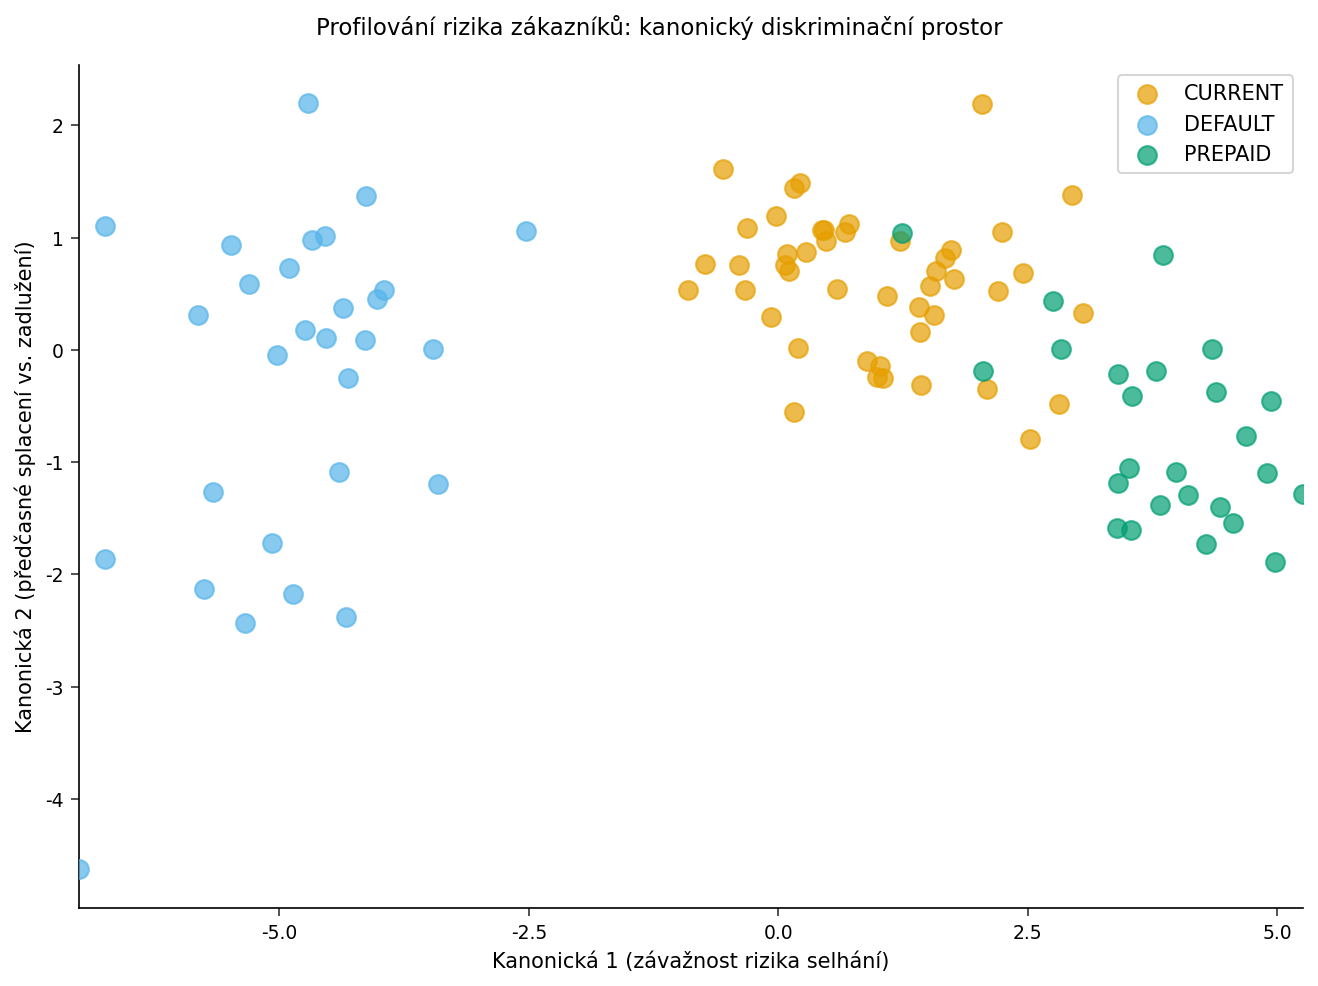

In [7]:
PROCEDURA SGPLOT data=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ŠTÍTEK="Kanonická 1 (závažnost rizika selhání)";
    YAXIS ŠTÍTEK="Kanonická 2 (předčasné splacení vs. zadlužení)";
    NÁZEV "Profilování rizika zákazníků: kanonický diskriminační prostor";
SPUSTIT;

---

### Interpretace

Dvě kanonické dimenze ostře oddělují tři skupiny stavu úvěru v rámci tohoto vzorku 100 zákazníků (46 splácených, 29 v prodlení, 25 předčasně splacených).

**Dimenze 1 — závažnost rizika prodlení (kanonická korelace 0,958, 91,8 % sdílené variance).** Tato osa sama o sobě představuje drtivou většinu oddělení skupin (vlastní číslo 11,20 oproti 0,34 pro druhou osu). Ve sdružené vnitrotřídní kanonické struktuře se nejsilněji nabíjí na využití úvěru (credit utilization, -0,595), poměr dluhu k příjmu (debt-to-income, -0,404), LTV (-0,370), měsíce v prodlení (-0,324) a poměr splátky k příjmu (payment-to-income, -0,304) — každý ukazatel zadlužení a zátěže míří stejným směrem. Protože zátěže jsou záporné, nízká (více záporná) skóre Can1 označují nejrizikovější dlužníky. Centroidy tříd to potvrzují: účty v prodlení leží na Can1 = -4,83, splácené účty na +0,96 a předčasně splacené účty na +3,84, čisté monotónní seřazení od nejhoršího po nejlepší úvěrové zdraví.

**Dimenze 2 — zadlužení versus nesplácení (kanonická korelace 0,503).** Druhá osa staví do kontrastu poměr LTV (+0,733) proti měsícům v prodlení (-0,700): odděluje dlužníky, kteří jsou vysoce zadlužení, ale splácejí, od těch, kteří nesou historii nesplácení. Zpřesňuje obraz uvnitř Can1, ale přispívá k oddělení mnohem méně, jak ukazují téměř shodné centroidy Can2 pro splácející skupiny (splácené +0,599, předčasně splacené -0,736).

**Oddělení skupin.** Umocněné Mahalanobisovy vzdálenosti mezi průměry tříd kvantifikují mezery: DEFAULT-k-PREPAID je největší při 75,3, DEFAULT-k-CURRENT je 34,3 a CURRENT-k-PREPAID je nejmenší při 10,1. Dvě splácející skupiny jsou proto blíže k sobě navzájem než kterákoli z nich ke skupině v prodlení, přesně jak by věřitel očekával.

**Praktické využití.** První kanonické skóre se chová jako hotový kompozitní index rizika: stlačuje šest korelovaných poměrů do jedné dobře oddělené dimenze, která seřazuje zákazníky od nejvyššího po nejnižší riziko prodlení. Portfoliové týmy mohou segmentovat podle mezních bodů (cut-points) Can1 a Mahalanobisovy vzdálenosti poskytují principiální základ pro přiřazení nového žadatele k nejbližší skupině stavu během kalibrace scorecardu.

---

### Export pro skórovací engine

Uchovejte kanonická skóre za jednotlivé zákazníky a dataset kanonických statistik (který nese centroidy a Mahalanobisovy vzdálenosti) pro následnou kalibraci scorecardu.

In [8]:
/* --------------------------------------------------------
   Export kanonických rizikových skóre a kanonických statistik
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>